In [163]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

#### read in the dataset and inspected the top two rows.

In [164]:
house_data = pd.read_csv('../ml-exercise-1-catdgomez/data/kc_house_data.csv')

In [165]:
house_data.head(2)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639


### 1. Before building the model, start by looking at a scatterplot of price vs. the square footage of living space. What do you find? How strong does the relationship appear to be?

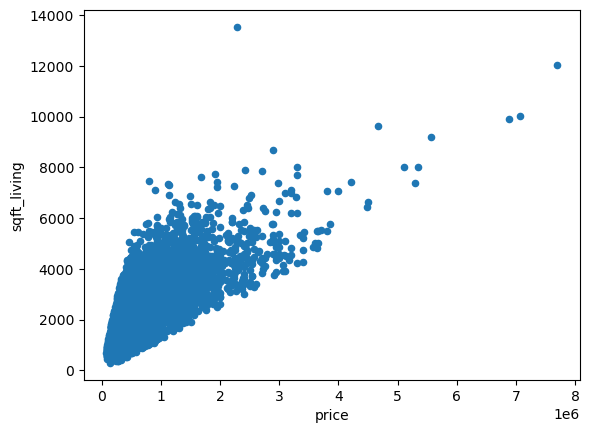

In [166]:
house_data.plot(kind = 'scatter', x = 'price', y = 'sqft_living');

Text(0.5, 1.0, 'Price vs. Sqft of living space')

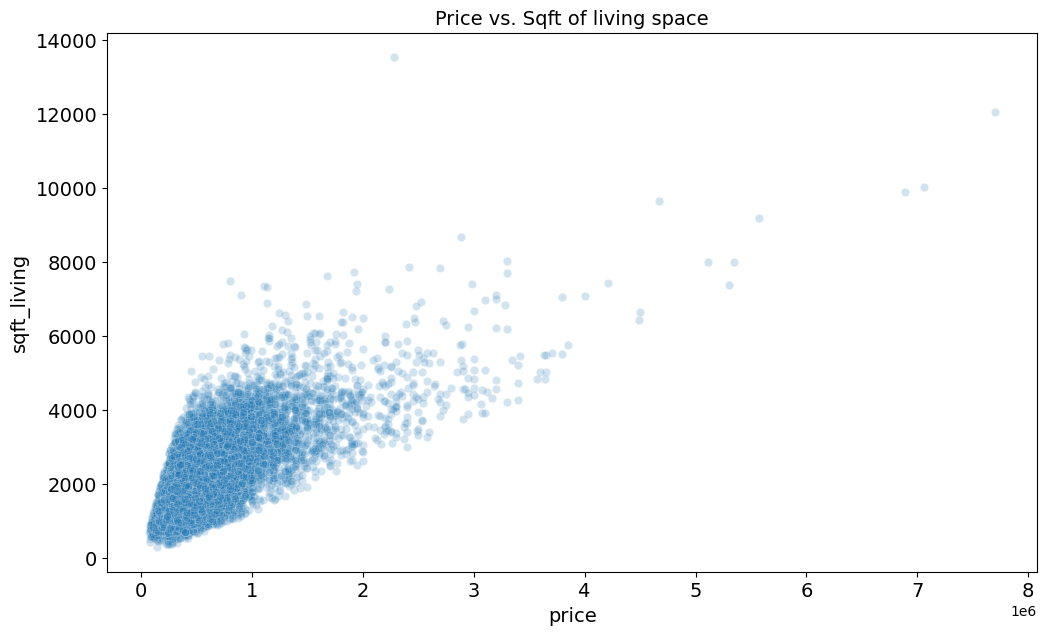

In [167]:
fontsize = 14
plt.figure(figsize = (12,7))
sns.scatterplot(data = house_data, x = 'price', y = 'sqft_living', alpha = 0.2)
plt.xticks(fontsize = fontsize)
plt.xlabel('price', fontsize = fontsize)
plt.yticks(fontsize = fontsize)
plt.ylabel('sqft_living', fontsize = fontsize)
plt.title('Price vs. Sqft of living space', fontsize = fontsize)
# house_data.plot(kind = 'scatter', x = 'price', y = 'sqft_living');

There appears to be a strong positive relationship between price and sqft of living space

### 2. In working toward building the model, I create a df, X, of the sqft_living space column and a series, y, of the target variable, price.

In [168]:
predictor_vars = ['sqft_living']

X = house_data[predictor_vars]
type(X)

pandas.core.frame.DataFrame

In [169]:
y = house_data['price']

In [170]:
X.head(2)

,sqft_living
0,1180
1,2570


In [171]:
y.head(2)

0    221900.0
1    538000.0
Name: price, dtype: float64

Inspect column titles, the 'view' column, and the types of objects created

In [172]:
house_data.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [173]:
house_data['view'].unique()

array([0, 3, 4, 2, 1])

In [174]:
type(house_data['price'])

pandas.core.series.Series

How well does the model predict on data that it has not yet seen? I set aside a portion of hte data as a test set to train the model on the remaining portion, which is one way to accomplish this. 

### 3. I use the train_test_split function to create a training and a test set from X and y. I name the resulting pieces X_train, X_test, y_train, y_test. I use 30% of the data in the test set and the random_state parameter so that I can compare model performance as I change the way I build my model. 

In [175]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, shuffle = True)

Now to fit my model beginning with a linear regression model.

### 4. Import the LinearRegression class from the linear_model module. Then create a linear regression instance and fit it to the training data.

In [176]:
linreg = LinearRegression().fit(X_train, y_train)

In [177]:
linreg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 5. What is the intercept term, and what is the coefficient for sqft_living? How can you interpret how the model is using sqft_living to make predictions? Hint: You can get these values by looking at the .intercept_ and .coef_ attributes of the fit model.

In [178]:
linreg.score(X_train, y_train)

0.4970072727500471

In [179]:
linreg.coef_

array([279.51011741])

In [180]:
linreg.intercept_

np.float64(-41947.45401876257)

How well does the model do on the unseen data?

### 6. Use the predict method to generate a set of predictions on X_test. Save the results to y_pred. Question: What type of object is y_pred? What is its shape and how does it compare to y_test?

In [181]:
linreg.predict(X_test)

array([ 536638.48902466,  768631.88647686, 1011805.68862555, ...,
        279489.18100536,  556204.19724352,  659622.94068607],
      shape=(6484,))

In [182]:
y_pred = linreg.predict(X_test)

In [183]:
type(y_pred)

numpy.ndarray

In [184]:
y_pred.shape

(6484,)

In [185]:
y_test.shape

(6484,)

Now, we can evaluate how well the model did. There are a number of different metrics that could be used. Let's look at five of them, mean squared error, root mean squared error, mean absolute error, mean absolute percentage error, and R^2 score. 

### 7. Calculate each metric on the test set. For each one, interpret what the number means.

In [186]:
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'MSE: It is a huge number, 74,000,000,000; you would not typically care what the MSE was unless you were comparing two models \nand the model with the lower MSE is the better model.\n')

print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'RMSE: Not super imporant at this point. Would like these top two numbers to be smaller.\n')

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAE: Directly interpretted, the magnitude of the error on average is 177,803. That is a pretty big number so when I make a \nprediction I could under or over estimating by 177,803, so it is pretty far off.\n')

print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'MAPE: On average I am off by about 36%, pretty big and not a great model and should not rely on these predictions.\n')

print(f'R2: {r2_score(y_test, y_pred)}')
print(f'R2: With R2, half the variance is explained by the predictor, but that means half of it is still unexplained.\n')

MSE: 74509993356.49603
MSE: It is a huge number, 74,000,000,000; you would not typically care what the MSE was unless you were comparing two models 
and the model with the lower MSE is the better model.

RMSE: 272965.1870779423
RMSE: Not super imporant at this point. Would like these top two numbers to be smaller.

MAE: 177803.0458452365
MAE: Directly interpretted, the magnitude of the error on average is 177,803. That is a pretty big number so when I make a 
prediction I could under or over estimating by 177,803, so it is pretty far off.

MAPE: 0.36040933275597725
MAPE: On average I am off by about 36%, pretty big and not a great model and should not rely on these predictions.

R2: 0.48388319278201475
R2: With R2, half the variance is explained by the predictor, but that means half of it is still unexplained.



I want to see how well my model performs against a simple baseline. In the case of regression, a very simple model would be one that just predicts the overall average home price on the training data.

### 8. Create a numpy array that is the same length as y_test which just contains a constant value equal to the mean of the target variable on the training data. Hint: you could use the full_like function from numpy to create this array. Does the model using sqft_living do better than this simple baseline model?

In [187]:
y_baseline = np.full_like(y_test, y_train.mean())

In [188]:
print(f'MSE: {mean_squared_error(y_test, y_baseline)}')
print(f'MSE: It is a huge number, 144,000,000,000,000; you would not typically care what the MSE was unless you were comparing two models \nand the model with the lower MSE is the better model.\n')

print(f'RMSE: {root_mean_squared_error(y_test, y_baseline)}')
print(f'RMSE: It looks like it is better on MSE.\n')

print(f'MAE: {mean_absolute_error(y_test, y_baseline)}')
print(f'MAE: Directly interpretted, the magnitude of the error on average is 237,674. That is a pretty big number so when I make a \nprediction I could under or over estimating by 237,647, so it is pretty far off and worse than the previous model.\n')

print(f'MAPE: {mean_absolute_percentage_error(y_test, y_baseline)}')
print(f'MAPE: On average I am off by about 53%, pretty big and not a great model and should not rely on these predictions.\n')

print(f'R2: {r2_score(y_test, y_baseline)}')
print(f'R2: With R2, which is pretty close to 0, if I had taken the mean of the test data instead of the training data it should be 0. If I am making any \npredictions, I can only predict based on the training data not on stuff I would know from the test data. Quite close to 0 but just slightly negative. \nThe model is improving the performance over the baseline, but there is still room for improvement.\n')

MSE: 144433113433.55414
MSE: It is a huge number, 144,000,000,000,000; you would not typically care what the MSE was unless you were comparing two models 
and the model with the lower MSE is the better model.

RMSE: 380043.56780973694
RMSE: It looks like it is better on MSE.

MAE: 237674.864169316
MAE: Directly interpretted, the magnitude of the error on average is 237,674. That is a pretty big number so when I make a 
prediction I could under or over estimating by 237,647, so it is pretty far off and worse than the previous model.

MAPE: 0.531175420949157
MAPE: On average I am off by about 53%, pretty big and not a great model and should not rely on these predictions.

R2: -0.0004611999523151944
R2: With R2, which is pretty close to 0, if I had taken the mean of the test data instead of the training data it should be 0. If I am making any 
predictions, I can only predict based on the training data not on stuff I would know from the test data. Quite close to 0 but just slightly negativ

There are other types of models besides a linear regression model. A k-nearest0neighbors model generates predictions by finding the most similar points in the training data and averaging their target values. It is a non-parametric model and doesn't assume a particular form for the relationship between the features and the target.

### 9. Fit a [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) to the data using just the square footage of living space and using 5 neighbors. How do the metrics compare to those for the linear regression model?

In [189]:
knn = KNeighborsRegressor(n_neighbors=5).fit(X_train, y_train)

In [190]:
y_pred = knn.predict(X_test)

In [209]:
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'MSE: It is a huge number, 79,000,000,000; you would not typically care what the MSE but since we are comparing \nmore than one model with the lower MSE is the better model. And it still appears that the linear regression model, \nwhile less flexible, it is out performing the KNeighborsRegressor.\n')

print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')
print(f'RMSE: It looks like it is worse on MSE.\n')

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MAE: Directly interpretted, the magnitude of the error on average is 185,369.\n')

print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'MAPE: On average I am off by about 38%.\n')

print(f'R2: {r2_score(y_test, y_pred)}')
print(f'R2: With R2, about half the variance is explained by the predictor, but that means half of it is still unexplained.\n')

MSE: 71339817814.27414
MSE: It is a huge number, 79,000,000,000; you would not typically care what the MSE but since we are comparing 
more than one model with the lower MSE is the better model. And it still appears that the linear regression model, 
while less flexible, it is out performing the KNeighborsRegressor.

RMSE: 267095.1474929377
RMSE: It looks like it is worse on MSE.

MAE: 171118.9834361505
MAE: Directly interpretted, the magnitude of the error on average is 185,369.

MAPE: 0.3505329073272551
MAPE: On average I am off by about 38%.

R2: 0.5058424066467072
R2: With R2, about half the variance is explained by the predictor, but that means half of it is still unexplained.



### 10. We can see how the KNN model has more flexibility than the Linear Regression model by plotting their predictions. Create a DataFrame which includes a range of typical square footage values. Hint: you can use the [numpy linspace function](https://numpy.org/doc/2.1/reference/generated/numpy.linspace.html). Generate 200 equally spaced values between 500 and 3000. Then generate predictions on these using both the linear regression and KNN model. Plot the predictions. What do you notice?

In [192]:
pred_df = pd.DataFrame({
    'sqft_living': np.linspace(500, 3000, 200)
})
pred_df

,sqft_living
0,500.000000
1,512.562814
2,525.125628
3,537.688442
4,550.251256
...,...
195,2949.748744
196,2962.311558
197,2974.874372
198,2987.437186


In [204]:
pred_df['lr_predictions'] = linreg.predict(pred_df[['sqft_living']])
pred_df['knn_predictions'] = knn.predict(pred_df[['sqft_living']])

In [197]:
pred_df

,sqft_living,lf_predictions,knn_predictions,lr_predictions
0,500.000000,97807.604687,185200.0,97807.604687
1,512.562814,101319.038323,327000.0,101319.038323
2,525.125628,104830.471959,371000.0,104830.471959
3,537.688442,108341.905595,363000.0,108341.905595
4,550.251256,111853.339231,196400.0,111853.339231
...,...,...,...,...
195,2949.748744,782537.163675,678140.0,782537.163675
196,2962.311558,786048.597311,753500.0,786048.597311
197,2974.874372,789560.030946,706400.0,789560.030946
198,2987.437186,793071.464582,752990.0,793071.464582


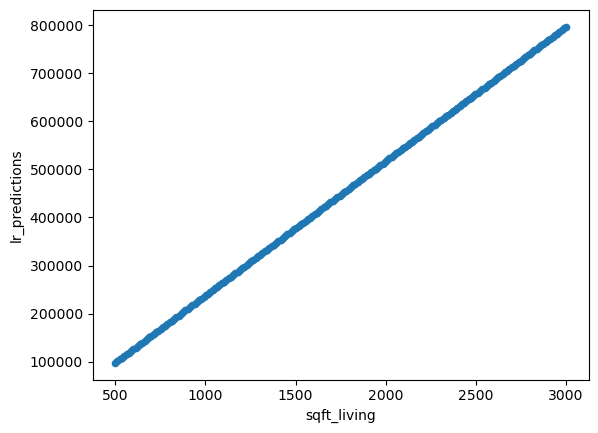

In [198]:
pred_df.plot(kind='scatter', x='sqft_living', y='lr_predictions');

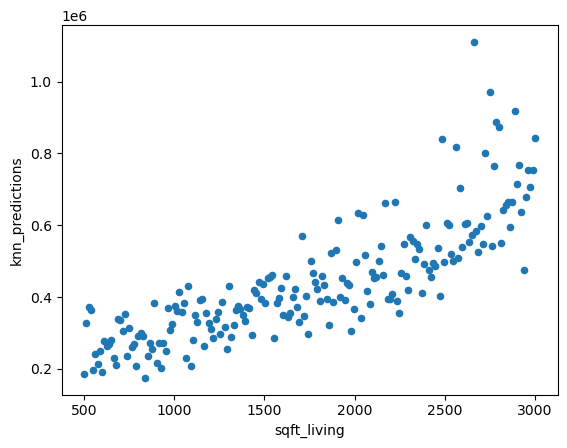

In [199]:
pred_df.plot(kind='scatter', x='sqft_living', y='knn_predictions');

Sure you have a more flexibile model but this was overfit to the data. If you average more points, it smoothes it out a bit.

In [201]:
knn = KNeighborsRegressor(n_neighbors=100).fit(X_train, y_train)

In [206]:
y_pred = knn.predict(X_test)

In [207]:
pred_df['knn_predictions'] = knn.predict(pred_df[['sqft_living']])

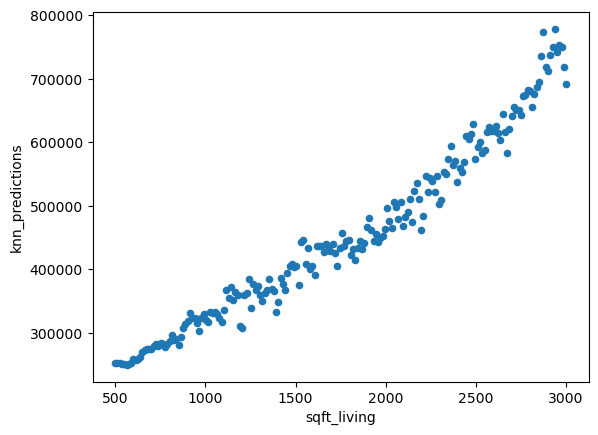

In [208]:
pred_df.plot(kind='scatter', x='sqft_living', y='knn_predictions');

### 11. Finally, let's see what happens when we add another variable. Create a new linear regression model which uses both the square footage of living space and whether or not it is waterfront. When you do this, make sure that you're using the same train and test split by using the same random_state as above. By how much does this improve the model's fit?

In [212]:
house_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [214]:
predictor_vars = ['sqft_living', 'waterfront']

X = house_data[predictor_vars]
y=house_data['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, shuffle = True)

In [216]:
linreg_waterfront = LinearRegression().fit(X_train, y_train)
y_pred = linreg_waterfront.predict(X_test)

In [220]:
print(f'MSE: {mean_squared_error(y_test, y_pred)}')

print(f'RMSE: {root_mean_squared_error(y_test, y_pred)}')

print(f'MAE: {mean_absolute_error(y_test, y_pred)}')

print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')

print(f'R2: {r2_score(y_test, y_pred)}')
print(f'Adding in that extra factor it helps but not a ton.\n')

MSE: 67664973042.120766
RMSE: 260124.9181491861
MAE: 173728.53303477002
MAPE: 0.3553730733351249
R2: 0.5312973700064663
Adding in that extra factor it helps but not a ton.

